# RNA-Seq and Microarray Data Exploration

### **Project Background:**
This project aims to compare the predictive capabilities of RNA-Seq and Microarray data in predicting Neuroblastoma outcomes using four supervised Machine Learning models.
<br> </br>
### **Notebook Aims:**

- **Load Data**: Load bulk RNA-Seq, Microarray and clinical metadata using Pandas and explore data missingness and descriptive statistics.

- **Scanpy Exploration**: Explore data using Scanpy and AnnData
  1. Quality Control
  2. Normalisation and Log Transformation
  3. Feature Selection
  4. Dimensionality Reduction
  5. Nearest neighbor graph construction and visualisation
  6. Marker genes

## Part 1: Import libraries

In [ ]:
!pip install -q scanpy anndata leidenalg

In [ ]:
import os
from google.colab import userdata

# Data handling
import pandas as pd
import numpy as np
import scanpy as sc

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

## Part 2: Load Data

In [ ]:
# --- Load data ---

file_path = userdata.get('DATA_PATH')

# RNA-Seq Gene expression data
df_rnaseq = pd.read_csv(f"{file_path}/log2FPKM.tsv", sep = "\t").rename({'00gene_id':'gene_id'},axis=1)
df_rnaseq = df_rnaseq.set_index(['gene_id'])
df_rnaseq.columns.name = 'ID'

# Microarray Gene expression data
df_microarray = pd.read_csv(f"{file_path}/allProbIntensities.tsv", sep = "\t").set_index(['Reporter.Identifier'])
df_microarray.columns.name = 'ID'

# Patient Info metadata
df_patient_info = pd.read_csv(f"{file_path}/patientInfo.tsv", sep = "\t").set_index('ID')
df_patient_info.columns.name = 'FactorValues'
df_patient_info = df_patient_info.sort_index(ascending=True)

## Part 3: RNA-Seq Data Exploration


In [ ]:
df_rnaseq

ID,NB001,NB002,NB003,NB004,NB005,NB006,NB007,NB008,NB009,NB010,...,NB489,NB490,NB491,NB492,NB493,NB494,NB495,NB496,NB497,NB498
gene_id,,,,,,,,,,,,,,,,,,,,,
1/2-SBSRNA4,0.834381,0.743094,0.909414,0.795775,0.905540,0.869154,1.811352,0.599240,0.981855,1.066399,...,0.997977,1.003559,0.842437,1.057873,0.805515,0.491331,0.868249,0.911379,0.660139,1.152988
A1BG,1.910053,0.941996,1.950857,1.989477,1.942946,1.927608,1.617745,2.161291,1.436439,2.159797,...,2.336929,2.836360,1.205317,2.439868,1.649027,1.451425,1.493852,1.641241,1.994978,1.289534
A1BG-AS1,1.453191,0.640614,1.156765,1.525277,1.365043,0.899212,1.304178,1.189205,0.771248,1.114787,...,1.182908,1.367371,0.643751,1.096815,0.925425,0.933275,1.208723,0.904511,1.529221,1.102866
A1CF,0.005102,0.005902,0.005192,0.000000,0.025347,0.005682,0.000000,0.000000,0.021880,0.000000,...,0.024298,0.007295,0.000000,0.006678,0.005746,0.004998,0.004853,0.000000,0.022780,0.018720
A2LD1,0.580151,0.738233,0.927667,0.936497,0.924853,0.739038,1.018705,0.546324,0.666877,0.865850,...,0.673627,1.401265,0.837443,0.939849,0.743496,0.957837,0.812093,0.488748,1.068072,0.782887
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ZYG11A,0.862512,0.051655,0.022912,0.108028,0.049621,0.264942,0.044684,0.000000,0.012183,0.021898,...,0.026980,0.094324,0.780477,0.043928,0.025368,0.011083,0.000000,0.070668,0.022501,0.031067
ZYG11B,3.561729,3.595790,2.236695,3.312516,2.235632,3.459969,3.130989,2.359791,2.361504,3.284610,...,2.827654,2.569946,3.569224,2.773570,3.690249,3.274257,3.380637,3.420162,3.462327,3.440527
ZYX,5.039327,5.144157,4.982975,6.142091,5.236531,6.108395,5.645258,5.018567,5.393207,5.730512,...,5.103993,4.754433,4.938587,4.572914,4.877509,5.591545,5.207842,5.346003,5.427338,5.148169


In [ ]:
df_patient_info

FactorValues,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.
ID,,,,,,
NB001,male,987,1.0,1.0,4,1.0
NB002,male,1808,NaN,NaN,NaN,NaN
NB003,female,625,1.0,1.0,4,1.0
NB004,female,335,NaN,NaN,NaN,NaN
NB005,female,536,1.0,1.0,4,1.0
...,...,...,...,...,...,...
NB494,male,56,NaN,NaN,NaN,NaN
NB495,male,163,0.0,0.0,1,0.0
NB496,male,132,NaN,NaN,NaN,NaN


In [ ]:
# Check for missing values in gene expression data
print("Missing values in Gene Expression Data:")
print(f"Total missing values: {df_rnaseq.isnull().sum().sum()}")
print(f"Rows with ANY missing values: {df_rnaseq.isnull().any(axis=1).sum()}")
print(f"Columns with missing values: {(df_rnaseq.isnull().sum() > 0).sum()}")

Missing values in Gene Expression Data:
Total missing values: 0
Rows with ANY missing values: 0
Columns with missing values: 0


In [ ]:
# Check for missing values in patient data
print("Missing values in Patient Data:")
print(f"Total missing values: {df_patient_info.isnull().sum().sum()}")
print(f"Rows with ANY missing values: {df_patient_info.isnull().any(axis=1).sum()}")

Missing values in Patient Data:
Total missing values: 996
Rows with ANY missing values: 249


In [ ]:
# Check which columns have missing values
print("\nColumns with missing values:")
print(df_patient_info.isnull().sum()[df_patient_info.isnull().sum() > 0])


Columns with missing values:
FactorValues
FactorValue..death.from.disease.    249
FactorValue..high.risk.             249
FactorValue..inss.stage.            249
FactorValue..progression.           249
dtype: int64


In [ ]:
outcome_columns = ['FactorValue..death.from.disease.',
                   'FactorValue..high.risk.',
                   'FactorValue..inss.stage.',
                   'FactorValue..progression.'
                   ]

all_identical = all(
    df_patient_info[outcome_columns[0]].isna().equals(df_patient_info[col].isna())
    for col in outcome_columns[1:]
)

print(f"All outcomes have identical missing patterns: {all_identical}")

All outcomes have identical missing patterns: True


In [ ]:
# Calculate library sizes (total counts per sample)
library_sizes = df_rnaseq.sum(axis=0)

print("Library sizes summary:")
print(library_sizes.describe())

Library sizes summary:
count      498.000000
mean     47026.315736
std       1337.069079
min      40685.010991
25%      46186.337930
50%      47079.176005
75%      47914.853331
max      50165.519159
dtype: float64


In [ ]:
# Match sample names
patient_ids = df_patient_info.index.values
df_rnaseq.columns = patient_ids
df_rnaseq = df_rnaseq.T

In [ ]:
# Merge dataframes
df_rnaseq = pd.concat([df_rnaseq, df_patient_info], axis=1)

In [ ]:
df_rnaseq = df_rnaseq[df_rnaseq['FactorValue..death.from.disease.'].notna()] # since All outcomes have identical missing patterns: True

In [ ]:
df_rnaseq

,1/2-SBSRNA4,A1BG,A1BG-AS1,A1CF,A2LD1,A2M,A2ML1,A2MP1,A4GALT,A4GNT,...,ZYG11B,ZYX,ZZEF1,ZZZ3,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.
NB001,0.834381,1.910053,1.453191,0.005102,0.580151,5.137167,0.027558,0.170671,1.535670,0.057101,...,3.561729,5.039327,3.245179,3.296496,male,987,1.0,1.0,4,1.0
NB003,0.909414,1.950857,1.156765,0.005192,0.927667,5.405414,0.028036,0.045284,0.943194,0.000000,...,2.236695,4.982975,2.880531,2.431521,female,625,1.0,1.0,4,1.0
NB005,0.905540,1.942946,1.365043,0.025347,0.924853,5.613060,0.000000,0.000000,1.549078,0.032056,...,2.235632,5.236531,2.761698,2.226502,female,536,1.0,1.0,4,1.0
NB007,1.811352,1.617745,1.304178,0.000000,1.018705,6.956301,0.000000,0.210127,1.959344,0.164813,...,3.130989,5.645258,2.755304,2.933508,male,942,0.0,1.0,4,1.0
NB009,0.981855,1.436439,0.771248,0.021880,0.666877,5.170205,0.000000,0.000000,1.374772,0.031028,...,2.361504,5.393207,2.730553,2.271136,female,217,0.0,1.0,4S,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NB489,0.997977,2.336929,1.182908,0.024298,0.673627,5.266052,0.000000,0.053645,0.854657,0.034626,...,2.827654,5.103993,3.519328,2.563558,female,865,0.0,1.0,4,0.0
NB491,0.842437,1.205317,0.643751,0.000000,0.837443,5.049343,0.000000,0.000000,1.025780,0.036918,...,3.569224,4.938587,2.949716,2.957478,male,2326,0.0,1.0,4,1.0
NB493,0.805515,1.649027,0.925425,0.005746,0.743496,5.223052,0.000000,0.050377,0.830303,0.000000,...,3.690249,4.877509,2.951646,3.293082,male,190,0.0,0.0,1,0.0
NB495,0.868249,1.493852,1.208723,0.004853,0.812093,6.655558,0.000000,0.124005,1.585030,0.157478,...,3.380637,5.207842,3.231953,3.206993,male,163,0.0,0.0,1,0.0


In [ ]:
# Sanity check for missing values
print("Missing values in df_rnaseq:")
print(f"Total missing values: {df_rnaseq.isnull().sum().sum()}")
print(f"Rows with ANY missing values: {df_rnaseq.isnull().any(axis=1).sum()}")

Missing values in df_rnaseq:
Total missing values: 0
Rows with ANY missing values: 0


In [ ]:
# Separate before Scanpy analysis

# Define your metadata columns
meta_cols = [
    'FactorValue..Sex.',
    'FactorValue..age.at.diagnosis.',
    'FactorValue..death.from.disease.',
    'FactorValue..high.risk.',
    'FactorValue..inss.stage.',
    'FactorValue..progression.'
]

# Separate gene expression from metadata
df_genes = df_rnaseq.drop(columns=meta_cols)
df_meta = df_rnaseq[meta_cols]

### Scanpy Preprocessing:

1. Quality Control
2. Normalisation and Log Transformation
3. Feature Selection
4. Dimensionality Reduction
5. Nearest neighbor graph construction and visualisation
6. Marker genes

### 1. Quality Control

In [ ]:
adata = sc.AnnData(X=df_genes.values,
                   obs=df_meta,
                   var=pd.DataFrame(index=df_genes.columns))

adata.obs_names = df_genes.index  # sample IDs
adata.var_names = df_genes.columns  # gene names

In [ ]:
adata

AnnData object with n_obs × n_vars = 249 × 23146
    obs: 'FactorValue..Sex.', 'FactorValue..age.at.diagnosis.', 'FactorValue..death.from.disease.', 'FactorValue..high.risk.', 'FactorValue..inss.stage.', 'FactorValue..progression.'

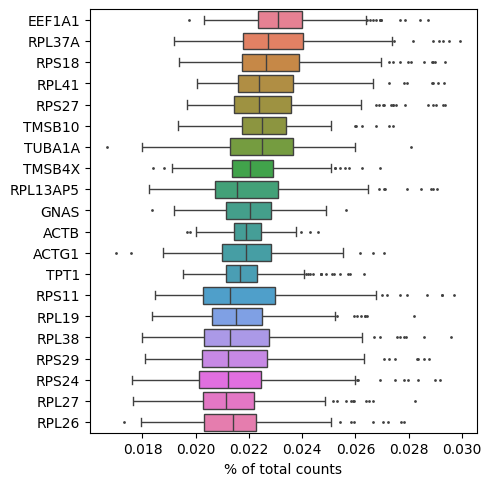

In [ ]:
sc.pl.highest_expr_genes(adata, n_top=20)

In [ ]:
# Check for Mt, Ribo and Hb genes:

# mitochondrial genes, "MT-" for human, "Mt-" for mouse
adata.var["mt"] = adata.var_names.str.startswith("MT-")
# ribosomal genes
adata.var["ribo"] = adata.var_names.str.startswith(("RPS", "RPL"))
# hemoglobin genes
adata.var["hb"] = adata.var_names.str.contains("^HB[^(P)]")

In [ ]:
print(f"Mitochondrial genes: {adata.var['mt'].sum()}")
print(f"Ribosomal genes: {adata.var['ribo'].sum()}")
print(f"Hemoglobin genes: {adata.var['hb'].sum()}")

# See the actual gene names
# print("\nMT genes:", adata.var_names[adata.var['mt']].tolist())
# print("Ribo genes:", adata.var_names[adata.var['ribo']].tolist())
# print("HB genes:", adata.var_names[adata.var['hb']].tolist())

Mitochondrial genes: 0
Ribosomal genes: 129
Hemoglobin genes: 18


In [ ]:
sc.pp.calculate_qc_metrics(adata, qc_vars=["ribo", "hb"], inplace=True, log1p=True)

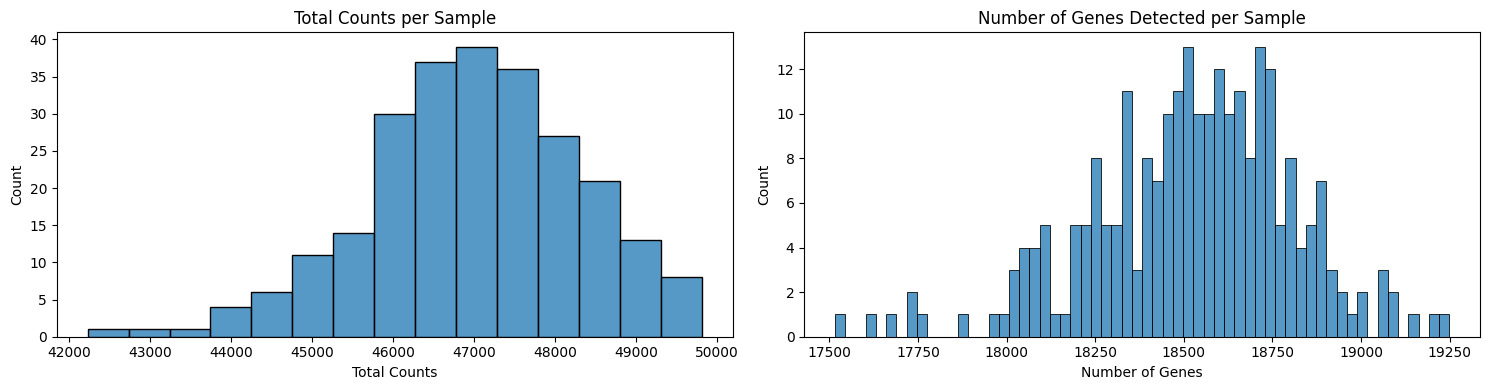

In [ ]:
# Histograms
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(adata.obs["total_counts"], kde=False, ax=axs[0])
axs[0].set_title('Total Counts per Sample')
axs[0].set_xlabel('Total Counts')

sns.histplot(adata.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[1])
axs[1].set_title('Number of Genes Detected per Sample')
axs[1].set_xlabel('Number of Genes')

plt.tight_layout()
plt.show()

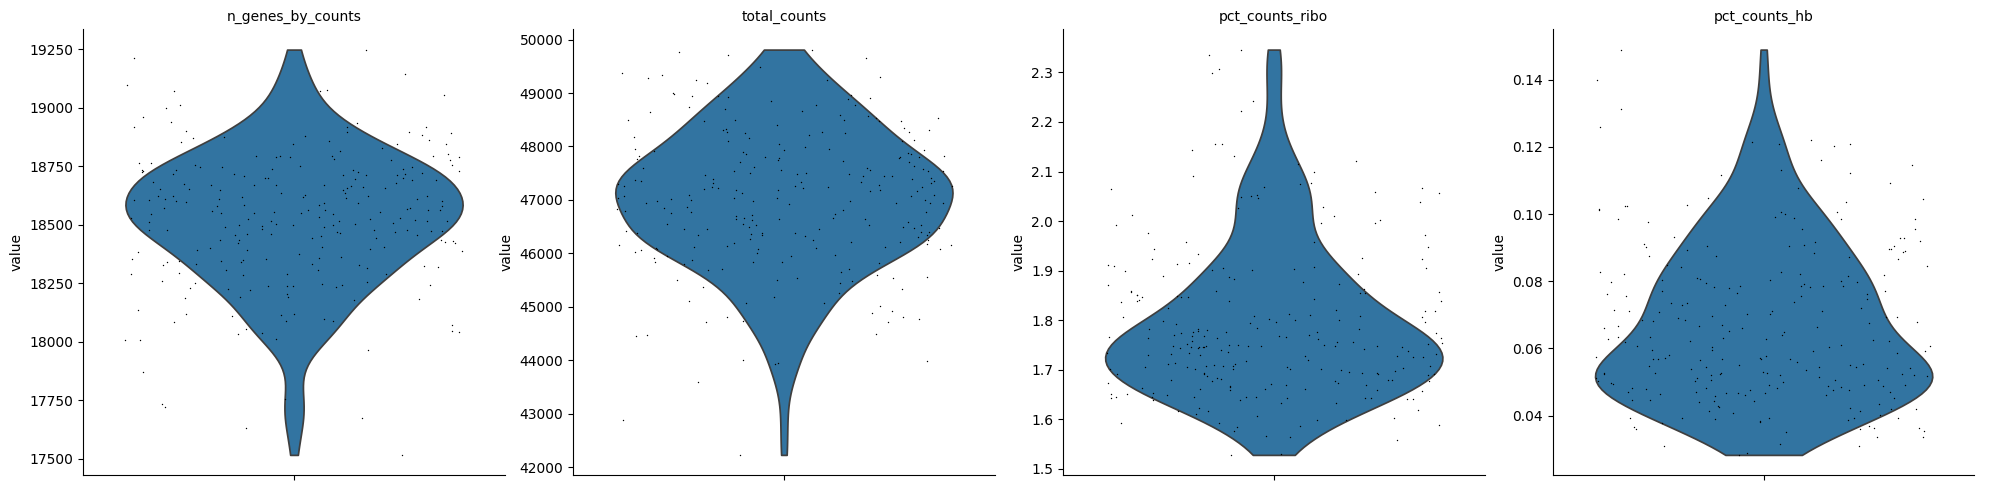

In [ ]:
# Violin plots
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts', 'pct_counts_ribo', 'pct_counts_hb'],
             jitter=0.4, multi_panel=True)

In [ ]:
sc.pp.filter_cells(adata, min_counts=44000)
sc.pp.filter_genes(adata, min_cells=10)

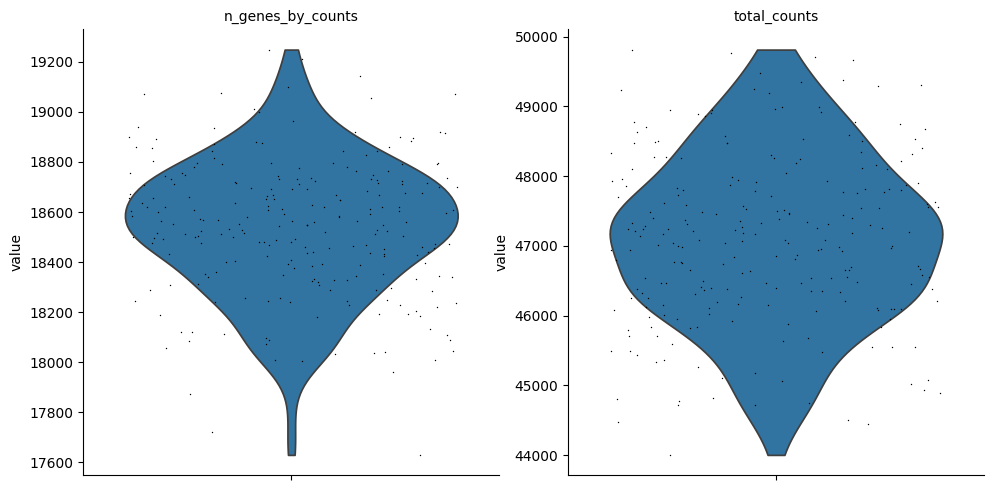

In [ ]:
sc.pl.violin(adata, ['n_genes_by_counts', 'total_counts'],
             jitter=0.4, multi_panel=True)

In [ ]:
adata

AnnData object with n_obs × n_vars = 243 × 20793
    obs: 'FactorValue..Sex.', 'FactorValue..age.at.diagnosis.', 'FactorValue..death.from.disease.', 'FactorValue..high.risk.', 'FactorValue..inss.stage.', 'FactorValue..progression.', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells'

### 2. Normalisation and Log Transformation

In [ ]:
# Is data really normalised?

print(adata.X.max()) # if raw then large integers
print(adata.X.min())
print(adata.X.mean())

# Check if values are integers (raw counts) or floats (normalised)
print(np.array_equal(adata.X, adata.X.astype(int)))  # True = raw counts

18.102862519567
0.0
2.264297282134217
False


In [ ]:
# Sum the gene expression counts across cells
gene_counts_sum = np.sum(adata.X, axis=0)
# Find the gene with the highest sum
gene_with_most_counts = adata.var_names[np.argmax(gene_counts_sum)]
print("Gene with the most counts:", gene_with_most_counts)

Gene with the most counts: EEF1A1


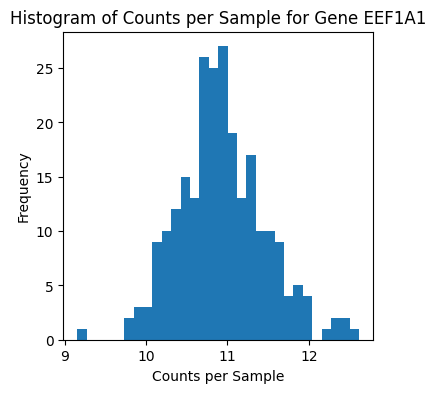

In [ ]:
gene_name = 'EEF1A1'
gene_index = list(adata.var_names).index(gene_name)
gene_counts_array = adata.X[:, gene_index].flatten()

plt.hist(gene_counts_array, bins=30)
plt.title(f"Histogram of Counts per Sample for Gene {gene_name}")
plt.xlabel("Counts per Sample")
plt.ylabel("Frequency")
plt.show()

In [ ]:
# Log transform
sc.pp.log1p(adata)

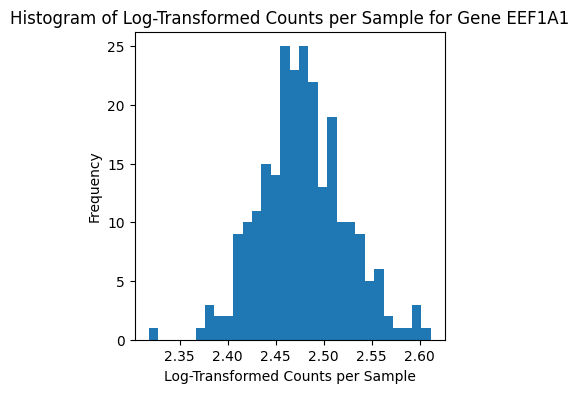

In [ ]:
# Get the log-transformed gene expression counts for the gene
gene_counts_log_transformed = adata.X[:, gene_index]

# Convert sparse matrix to array
gene_counts_log_transformed_array = gene_counts_log_transformed.flatten()

# Plot the histogram
plt.hist(gene_counts_log_transformed_array, bins=30)
plt.title(f"Histogram of Log-Transformed Counts per Sample for Gene {gene_name}")
plt.xlabel("Log-Transformed Counts per Sample")
plt.ylabel("Frequency")
plt.show()

### 3. Feature selection

In [ ]:
sc.pp.highly_variable_genes(adata, flavor="seurat", n_top_genes=2000)

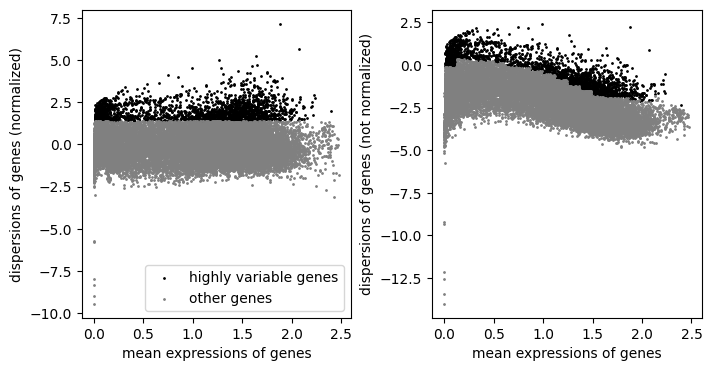

In [ ]:
sc.pl.highly_variable_genes(adata)

In [ ]:
adata = adata[:, adata.var.highly_variable]

In [ ]:
adata

View of AnnData object with n_obs × n_vars = 243 × 2000
    obs: 'FactorValue..Sex.', 'FactorValue..age.at.diagnosis.', 'FactorValue..death.from.disease.', 'FactorValue..high.risk.', 'FactorValue..inss.stage.', 'FactorValue..progression.', 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'pct_counts_in_top_50_genes', 'pct_counts_in_top_100_genes', 'pct_counts_in_top_200_genes', 'pct_counts_in_top_500_genes', 'total_counts_ribo', 'log1p_total_counts_ribo', 'pct_counts_ribo', 'total_counts_hb', 'log1p_total_counts_hb', 'pct_counts_hb', 'n_counts'
    var: 'mt', 'ribo', 'hb', 'n_cells_by_counts', 'mean_counts', 'log1p_mean_counts', 'pct_dropout_by_counts', 'total_counts', 'log1p_total_counts', 'n_cells', 'highly_variable', 'means', 'dispersions', 'dispersions_norm'
    uns: 'log1p', 'hvg'

### 4. Dimensionality Reduction

In [ ]:
sc.pp.pca(adata)

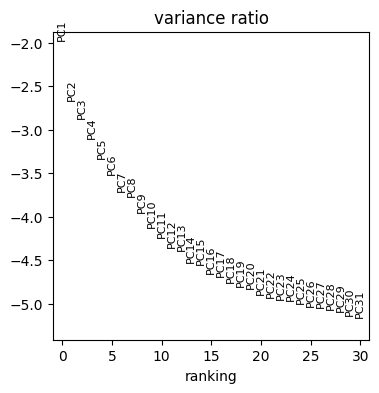

In [ ]:
sc.pl.pca_variance_ratio(adata, log=True)

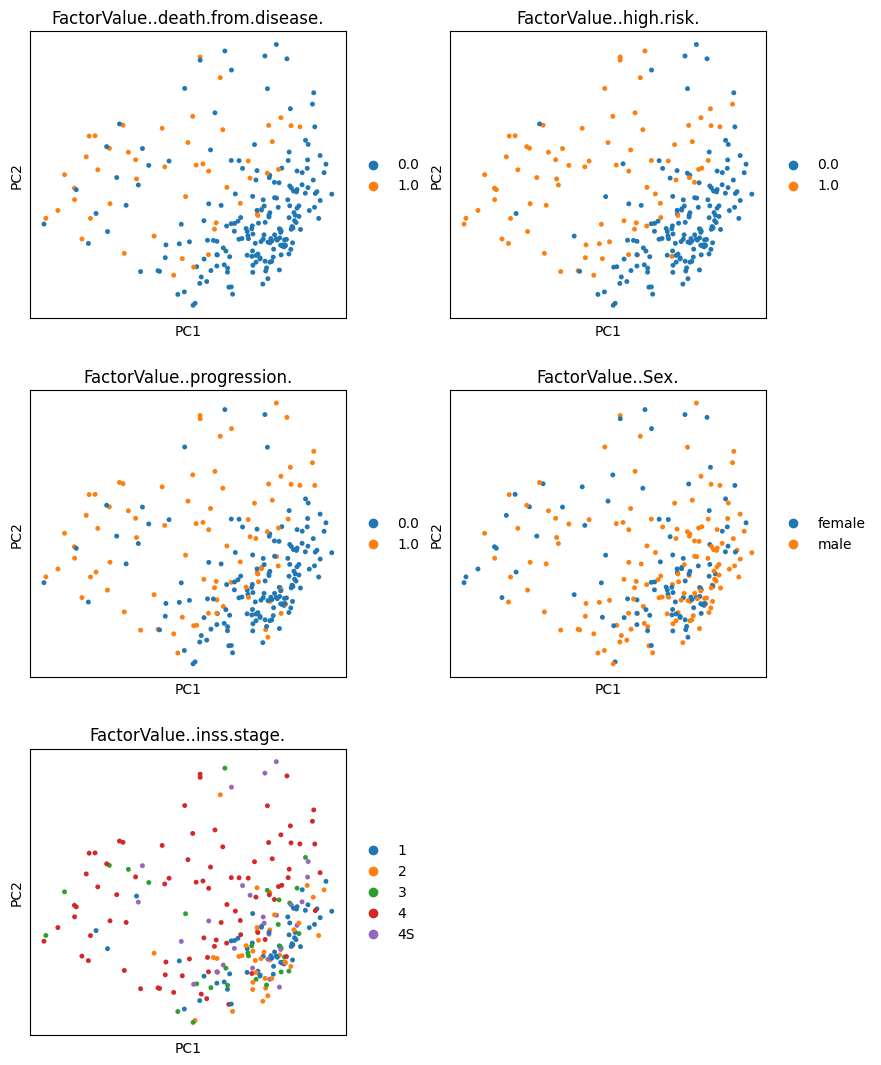

In [ ]:
# Convert to categorical fir plotting
adata.obs["FactorValue..death.from.disease."] = adata.obs["FactorValue..death.from.disease."].astype(str).astype("category")
adata.obs["FactorValue..high.risk."] = adata.obs["FactorValue..high.risk."].astype(str).astype("category")
adata.obs["FactorValue..progression."] = adata.obs["FactorValue..progression."].astype(str).astype("category")

# Plot
sc.pl.pca(
    adata,
    color=["FactorValue..death.from.disease.", "FactorValue..high.risk.", "FactorValue..progression.", "FactorValue..Sex.", "FactorValue..inss.stage."],
    dimensions=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)],
    ncols=2,
    size=50,
)

### 5. Nearest neighbor graph construction and visualisation

In [ ]:
sc.pp.neighbors(adata, n_pcs=20)

In [ ]:
sc.tl.umap(adata, n_components=2)

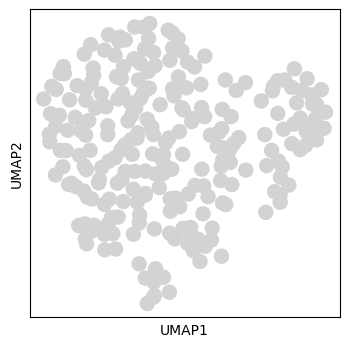

In [ ]:
sc.pl.umap(adata)

In [ ]:
sorted_by_num_cells = adata.var['n_cells_by_counts'].sort_values(ascending=False)
sorted_by_num_cells

,n_cells_by_counts
ZAP70,249
XIST,249
XAF1,249
WSB1,249
WNK2,249
...,...
SNORA80B,11
SNORA16B,10
MIR1248,10
SNORA5B,10


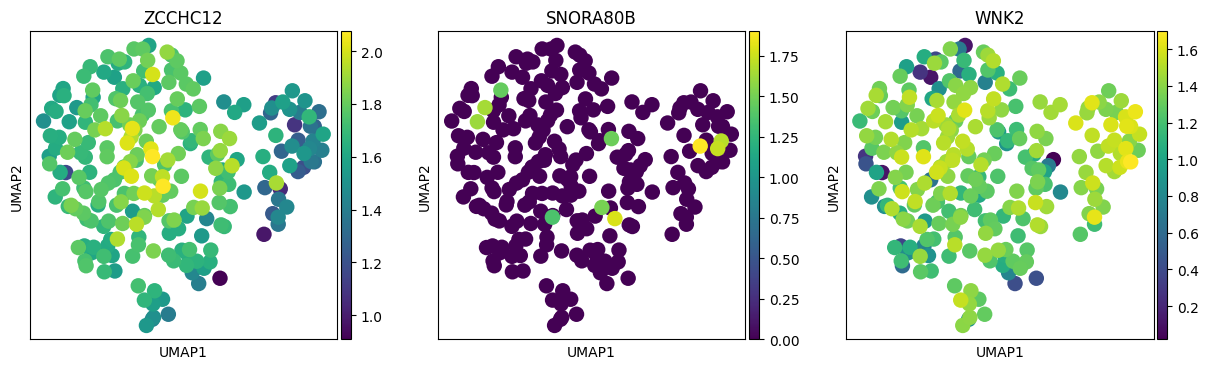

In [ ]:
# Colour by genes
sc.pl.umap(adata, color=["ZCCHC12", "SNORA80B", "WNK2"])

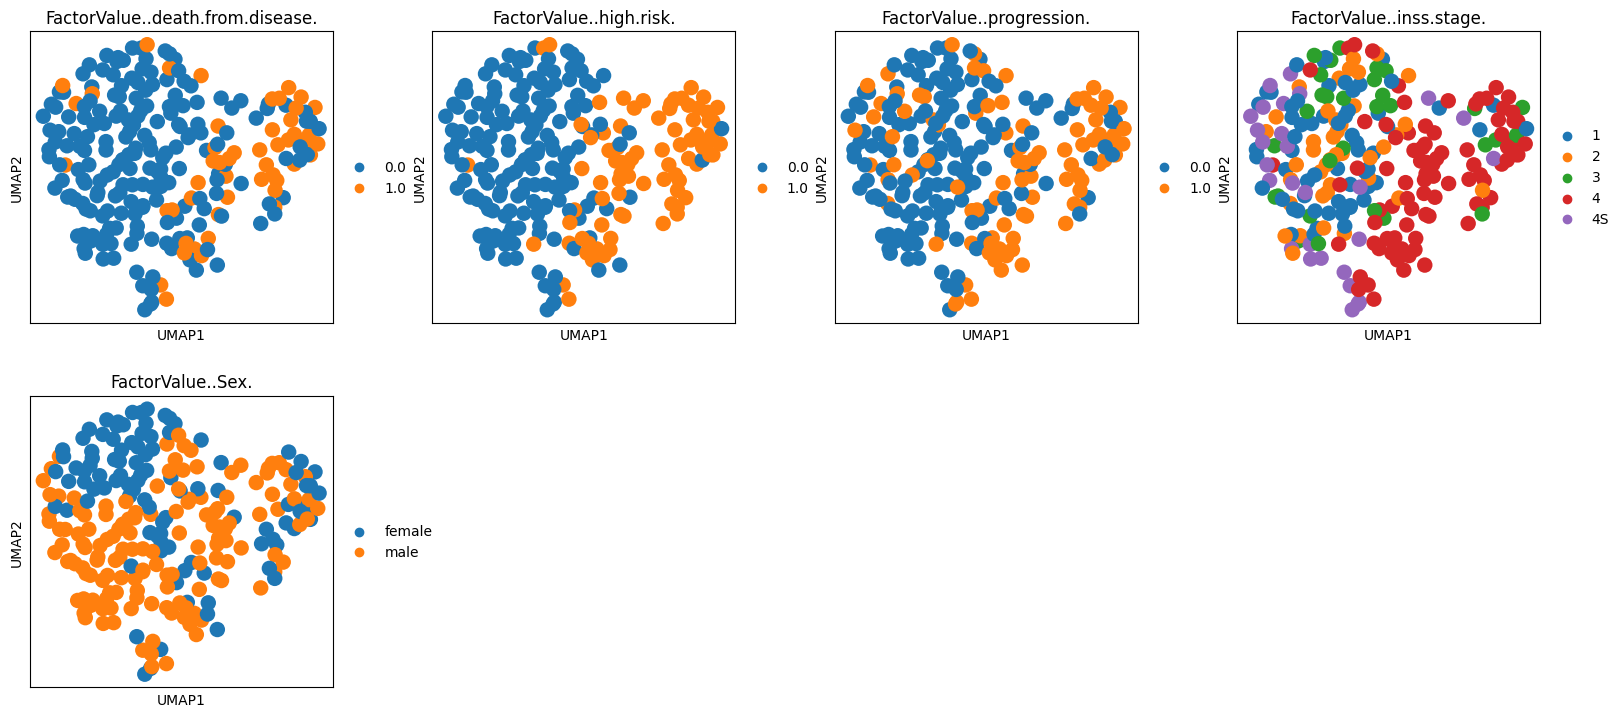

In [ ]:
# Colour by clinical outcomes
sc.pl.umap(adata, color=["FactorValue..death.from.disease.", "FactorValue..high.risk.", "FactorValue..progression.", "FactorValue..inss.stage.", "FactorValue..Sex."])

In [ ]:
sc.tl.leiden(adata, resolution=0.6, key_added="clusters")

In [ ]:
adata.obs

,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.,n_genes_by_counts,log1p_n_genes_by_counts,total_counts,log1p_total_counts,...,pct_counts_in_top_200_genes,pct_counts_in_top_500_genes,total_counts_ribo,log1p_total_counts_ribo,pct_counts_ribo,total_counts_hb,log1p_total_counts_hb,pct_counts_hb,n_counts,clusters
NB001,male,987,1.0,1.0,4,1.0,18940,9.849084,49342.328962,10.806558,...,3.510320,7.600277,815.120172,6.704562,1.651969,23.143576,3.184018,0.046904,49342.328962,3
NB003,female,625,1.0,1.0,4,1.0,18385,9.819345,45879.899384,10.733804,...,4.001272,8.465198,914.023147,6.818949,1.992208,14.237863,2.723783,0.031033,45879.899384,2
NB005,female,536,1.0,1.0,4,1.0,18553,9.828441,46381.062249,10.744668,...,3.913522,8.336689,873.620827,6.773790,1.883572,22.760040,3.168005,0.049072,46381.062249,2
NB007,male,942,0.0,1.0,4,1.0,19001,9.852300,48527.828631,10.789913,...,3.590996,7.769866,820.742893,6.711428,1.691283,20.666271,3.075757,0.042586,48527.828631,3
NB009,female,217,0.0,1.0,4S,0.0,18726,9.837722,47807.558711,10.774960,...,3.831234,8.246760,884.259906,6.785881,1.849624,48.989580,3.911815,0.102472,47807.558711,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NB489,female,865,0.0,1.0,4,0.0,18180,9.808132,44445.030011,10.702031,...,4.095860,8.640879,909.692268,6.814205,2.046781,31.276167,3.474329,0.070370,44445.030011,2
NB491,male,2326,0.0,1.0,4,1.0,18436,9.822115,47394.484013,10.766282,...,3.784152,8.257581,844.681117,6.740142,1.782235,22.530877,3.158313,0.047539,47394.484013,3
NB493,male,190,0.0,0.0,1,0.0,18284,9.813836,46349.378848,10.743985,...,3.632502,7.995078,762.367367,6.637739,1.644828,42.441341,3.771412,0.091568,46349.378848,0
NB495,male,163,0.0,0.0,1,0.0,18733,9.838095,47782.687641,10.774440,...,3.630876,7.904150,816.443956,6.706182,1.708661,47.045132,3.872141,0.098456,47782.687641,1


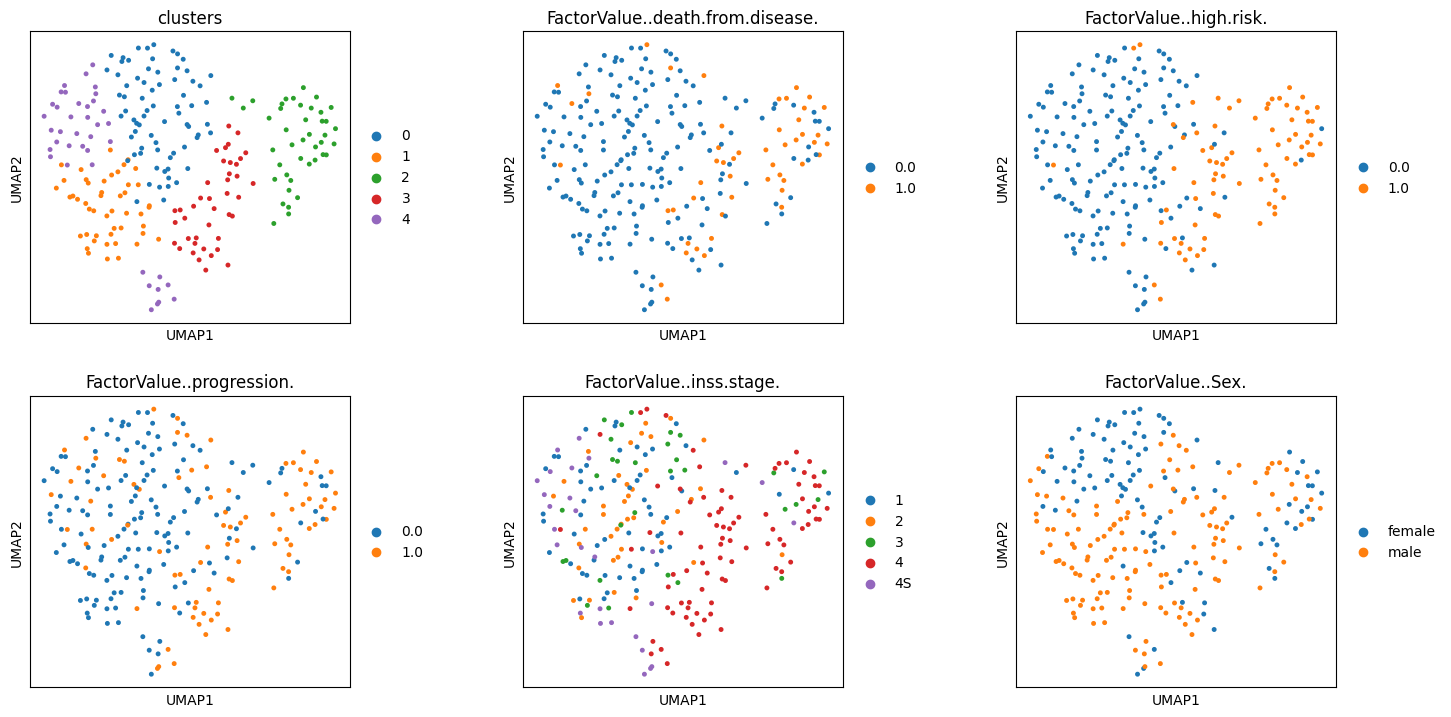

In [ ]:
sc.pl.umap(adata,
           color=["clusters", "FactorValue..death.from.disease.",
                  "FactorValue..high.risk.", "FactorValue..progression.",
                  "FactorValue..inss.stage.", "FactorValue..Sex."],
           wspace=0.4, ncols=3, size=50)

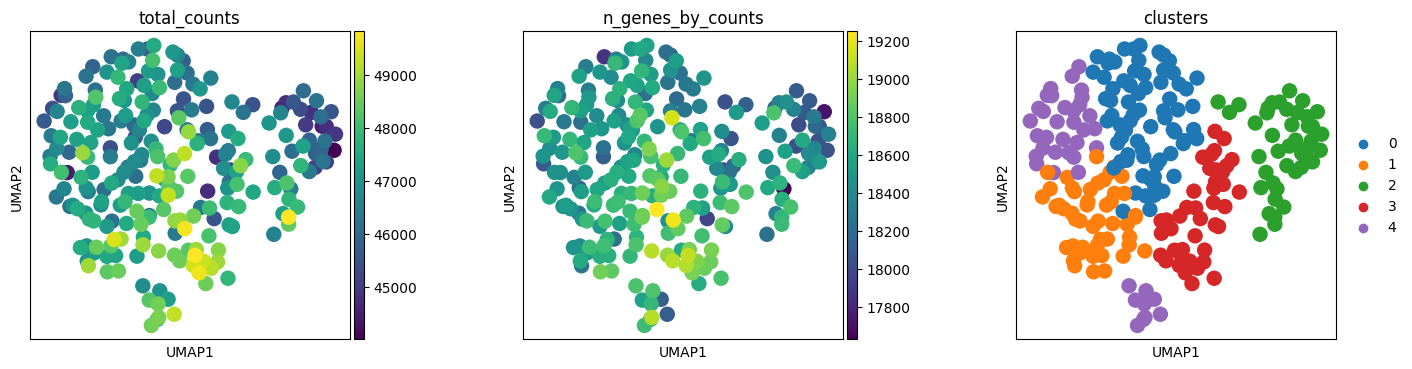

In [ ]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)

### 6. Marker genes

In [ ]:
sc.tl.rank_genes_groups(adata, "clusters", method="t-test")

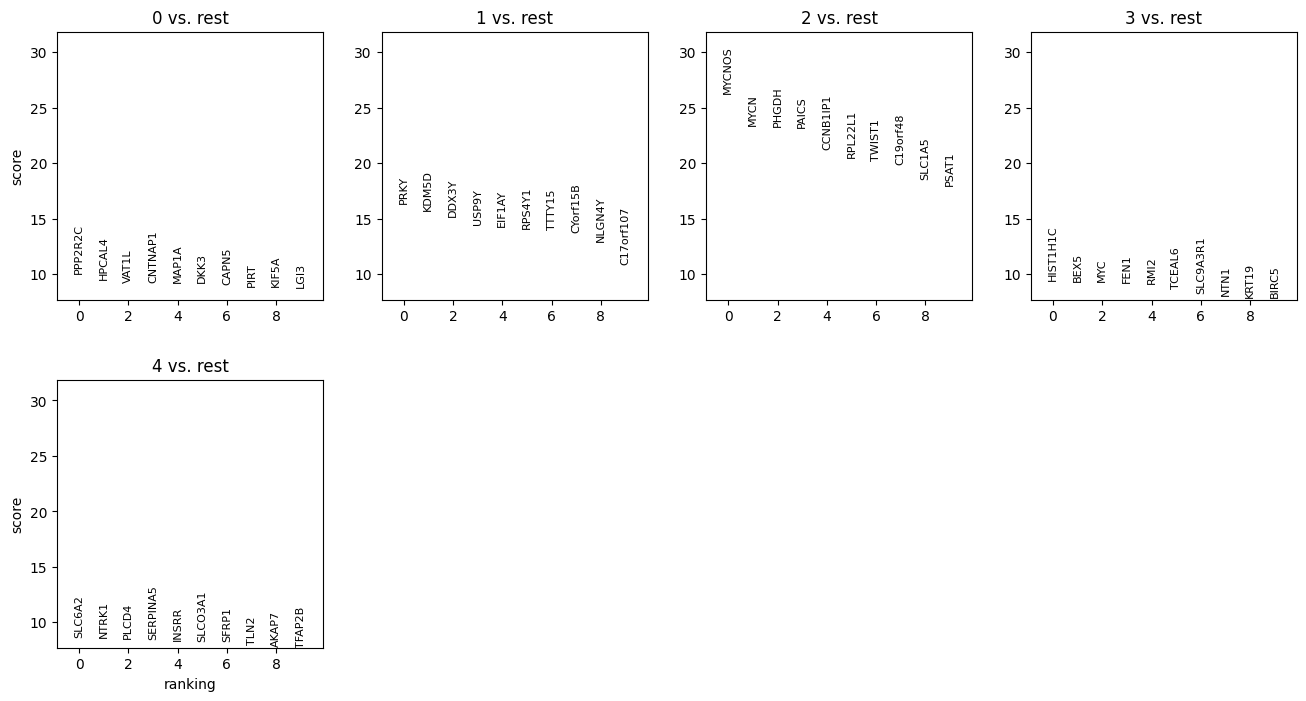

In [ ]:
sc.pl.rank_genes_groups(adata, n_genes=10)

categories: 0, 1, 2, etc.
var_group_labels: 0, 1


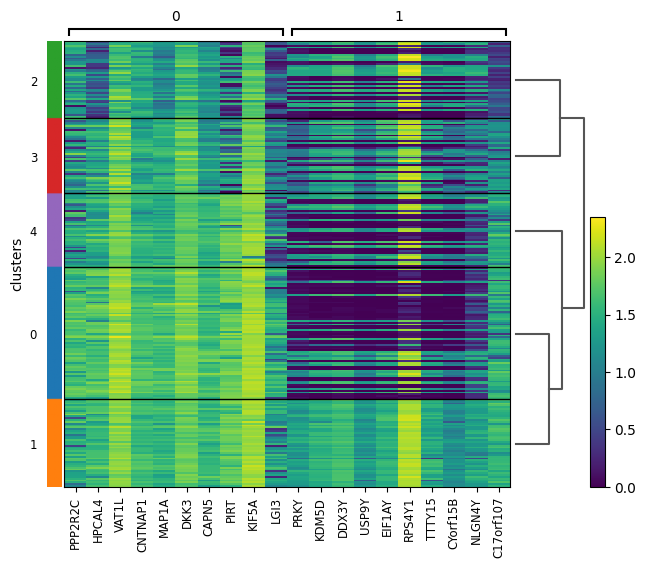

In [ ]:
# Show marker genes for multiple clusters
sc.pl.rank_genes_groups_heatmap(adata, groups=["0", "1"], n_genes=10, groupby="clusters")

In [ ]:
# Obtain the top features for each cluster
result = adata.uns["rank_genes_groups"]
groups = result["names"].dtype.names
top_features = {}
n_top_genes = 10  # desired number of top genes per cluster
for group in groups:
    top_features[group] = result["names"][group][:n_top_genes]

# Print the top features for each cluster
for group, features in top_features.items():
    print(f"Cluster {group} top features:")
    for feature in features:
        print(feature)
    print()

Cluster 0.0 top features:
WSB1
NRBP2
PGM2L1
C17orf107
SRCIN1
CAPN5
PLXNA4
PLEKHG5
GDPD5
PCDHGB6

Cluster 1.0 top features:
MAD2L1
CKS2
CDKN3
UHRF1
PTTG1
HMGB2
MCM2
MLF1IP
CCNA2
CDK1



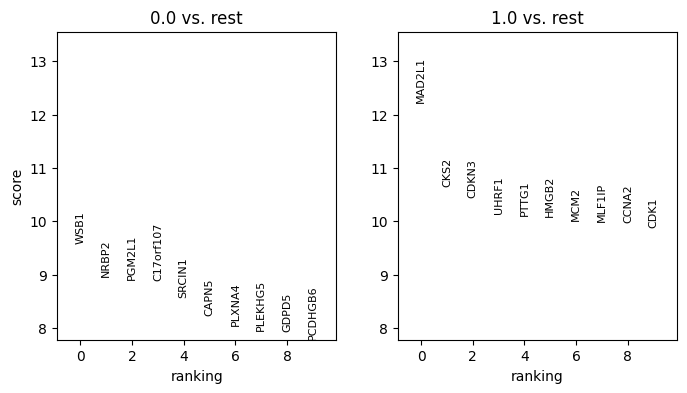

In [ ]:
# Rank genes by outcome
sc.tl.rank_genes_groups(adata, "FactorValue..death.from.disease.", method="t-test")
sc.pl.rank_genes_groups(adata, n_genes=10)

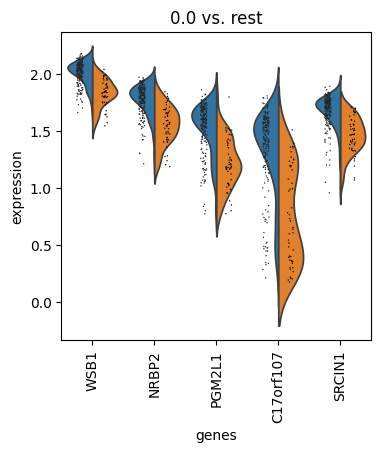

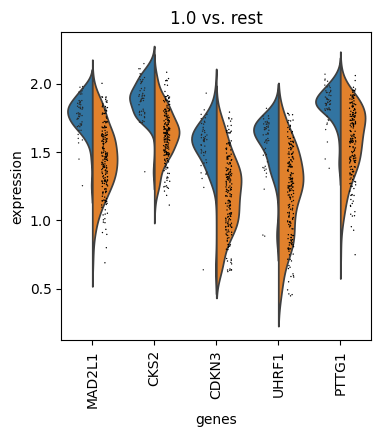

In [ ]:
# After ranking genes by outcome, plot top genes
sc.pl.rank_genes_groups_violin(adata, groups=["0.0", "1.0"], n_genes=5)

## Part 4: Microarray Data Exploration

In [ ]:
df_microarray

ID,GeneSymbols,NB001,NB002,NB003,NB004,NB005,NB006,NB007,NB008,NB009,...,NB489,NB490,NB491,NB492,NB493,NB494,NB495,NB496,NB497,NB498
Reporter.Identifier,,,,,,,,,,,,,,,,,,,,,
28913,NaN,14.99,14.94,12.48,14.63,11.89,15.09,13.07,12.00,11.70,...,13.62,13.03,14.98,13.36,13.90,13.00,13.79,14.70,14.03,12.31
27262,NaN,9.20,10.41,9.27,8.83,7.97,10.33,9.62,8.72,9.36,...,6.26,5.93,6.97,5.99,7.62,7.76,8.56,7.74,7.57,7.08
3180,NaN,5.06,5.26,6.45,2.89,2.00,4.80,3.05,6.39,6.43,...,0.93,0.58,1.26,1.38,3.49,2.07,2.26,2.29,2.63,2.54
41426,MBL1P,7.45,8.68,6.30,7.30,6.26,7.50,7.43,6.98,8.02,...,5.35,5.57,5.51,6.30,6.60,6.38,7.49,6.77,8.13,7.11
37033,NaN,6.74,6.63,6.75,6.20,6.57,6.01,6.78,4.80,5.15,...,4.58,4.61,3.54,4.55,4.20,7.16,7.07,5.07,6.28,6.34
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22435,NaN,10.35,10.33,9.81,10.36,9.65,10.46,9.17,10.23,10.16,...,8.60,7.37,8.22,8.44,10.17,9.95,10.09,9.68,9.98,9.40
17350,NaN,17.05,16.62,17.45,16.72,16.93,17.69,16.85,18.07,16.98,...,17.14,16.79,16.03,16.71,16.46,16.83,17.16,17.24,17.11,16.42
28875,NaN,5.30,6.84,5.29,5.33,4.81,6.62,6.52,5.37,5.65,...,4.07,3.05,2.77,4.14,3.94,4.19,6.85,4.99,4.51,3.34


In [ ]:
# Check for missing values in gene expression data
print("Missing values in Gene Expression Data:")
print(f"Total missing values: {df_microarray.isnull().sum().sum()}")
print(f"Rows with ANY missing values: {df_microarray.isnull().any(axis=1).sum()}")
print(f"Columns with missing values: {(df_microarray.isnull().sum() > 0).sum()}")

Missing values in Gene Expression Data:
Total missing values: 740526
Rows with ANY missing values: 34860
Columns with missing values: 499


In [ ]:
# Remove genes where ALL samples are NaN
df_microarray = df_microarray.dropna(how='all')
print(f"Genes remaining after filtering: {df_microarray.shape[0]}")
print(f"Genes removed (all NaN): {df_microarray.shape[0] - df_microarray.shape[0]}")

# Optional: Check if there are any remaining NaNs
remaining_nans = df_microarray.isnull().sum().sum()
print(f"Remaining NaN values: {remaining_nans}")

Genes remaining after filtering: 43291
Genes removed (all NaN): 0
Remaining NaN values: 33443


In [ ]:
df_microarray = df_microarray.drop(columns='GeneSymbols')

In [ ]:
# Match sample names
patient_ids = df_patient_info.index.values
df_microarray.columns = patient_ids
df_microarray = df_microarray.T

In [ ]:
# Merge dataframes
df_microarray = pd.concat([df_microarray, df_patient_info], axis=1)

In [ ]:
df_microarray

,28913,27262,3180,41426,37033,6190,4123,21664,10745,13510,...,17350,28875,8993,32006,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.
NB001,14.99,9.20,5.06,7.45,6.74,3.84,17.27,12.14,3.04,7.85,...,17.05,5.30,13.91,14.54,male,987,1.0,1.0,4,1.0
NB002,14.94,10.41,5.26,8.68,6.63,4.05,17.00,12.36,4.10,7.58,...,16.62,6.84,13.57,14.45,male,1808,NaN,NaN,NaN,NaN
NB003,12.48,9.27,6.45,6.30,6.75,4.91,17.79,11.72,4.27,7.82,...,17.45,5.29,13.63,14.33,female,625,1.0,1.0,4,1.0
NB004,14.63,8.83,2.89,7.30,6.20,3.00,17.45,11.31,4.12,7.01,...,16.72,5.33,13.84,14.76,female,335,NaN,NaN,NaN,NaN
NB005,11.89,7.97,2.00,6.26,6.57,2.07,17.38,10.90,3.10,6.50,...,16.93,4.81,13.22,14.61,female,536,1.0,1.0,4,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NB494,13.00,7.76,2.07,6.38,7.16,2.20,17.18,11.45,3.45,6.77,...,16.83,4.19,13.50,13.82,male,56,NaN,NaN,NaN,NaN
NB495,13.79,8.56,2.26,7.49,7.07,2.41,17.50,12.18,2.29,6.77,...,17.16,6.85,14.26,14.82,male,163,0.0,0.0,1,0.0
NB496,14.70,7.74,2.29,6.77,5.07,2.38,17.51,11.94,2.20,6.42,...,17.24,4.99,13.99,14.17,male,132,NaN,NaN,NaN,NaN
NB497,14.03,7.57,2.63,8.13,6.28,2.72,17.83,12.22,2.49,7.01,...,17.11,4.51,14.37,14.65,female,379,0.0,0.0,1,0.0


In [ ]:
df_microarray = df_microarray[df_microarray['FactorValue..death.from.disease.'].notna()]

In [ ]:
df_microarray

,28913,27262,3180,41426,37033,6190,4123,21664,10745,13510,...,17350,28875,8993,32006,FactorValue..Sex.,FactorValue..age.at.diagnosis.,FactorValue..death.from.disease.,FactorValue..high.risk.,FactorValue..inss.stage.,FactorValue..progression.
NB001,14.99,9.20,5.06,7.45,6.74,3.84,17.27,12.14,3.04,7.85,...,17.05,5.30,13.91,14.54,male,987,1.0,1.0,4,1.0
NB003,12.48,9.27,6.45,6.30,6.75,4.91,17.79,11.72,4.27,7.82,...,17.45,5.29,13.63,14.33,female,625,1.0,1.0,4,1.0
NB005,11.89,7.97,2.00,6.26,6.57,2.07,17.38,10.90,3.10,6.50,...,16.93,4.81,13.22,14.61,female,536,1.0,1.0,4,1.0
NB007,13.07,9.62,3.05,7.43,6.78,3.58,17.44,10.85,3.72,7.84,...,16.85,6.52,13.71,14.27,male,942,0.0,1.0,4,1.0
NB009,11.70,9.36,6.43,8.02,5.15,5.21,17.38,12.08,4.32,7.34,...,16.98,5.65,13.72,14.75,female,217,0.0,1.0,4S,0.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
NB489,13.62,6.26,0.93,5.35,4.58,0.77,17.32,11.37,1.54,6.18,...,17.14,4.07,13.00,13.72,female,865,0.0,1.0,4,0.0
NB491,14.98,6.97,1.26,5.51,3.54,1.38,16.60,11.21,1.20,5.38,...,16.03,2.77,12.97,13.56,male,2326,0.0,1.0,4,1.0
NB493,13.90,7.62,3.49,6.60,4.20,2.07,17.18,12.38,4.22,6.76,...,16.46,3.94,14.19,13.76,male,190,0.0,0.0,1,0.0
NB495,13.79,8.56,2.26,7.49,7.07,2.41,17.50,12.18,2.29,6.77,...,17.16,6.85,14.26,14.82,male,163,0.0,0.0,1,0.0


In [ ]:
# Separate before Scanpy analysis

# Define your metadata columns
meta_cols = [
    'FactorValue..Sex.',
    'FactorValue..age.at.diagnosis.',
    'FactorValue..death.from.disease.',
    'FactorValue..high.risk.',
    'FactorValue..inss.stage.',
    'FactorValue..progression.'
]

# Separate gene expression from metadata
df_genes = df_microarray.drop(columns=meta_cols)
df_meta = df_microarray[meta_cols]

### Scanpy analysis:


In [ ]:
adata_ma = sc.AnnData(X=df_genes.values,
                   obs=df_meta,
                   var=pd.DataFrame(index=df_genes.columns))

adata_ma.obs_names = df_genes.index  # sample IDs
adata_ma.var_names = df_genes.columns  # gene names

In [ ]:
adata_ma

AnnData object with n_obs × n_vars = 249 × 43291
    obs: 'FactorValue..Sex.', 'FactorValue..age.at.diagnosis.', 'FactorValue..death.from.disease.', 'FactorValue..high.risk.', 'FactorValue..inss.stage.', 'FactorValue..progression.'

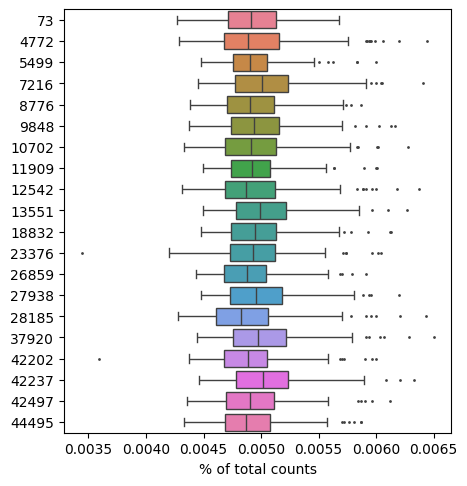

In [ ]:
sc.pl.highest_expr_genes(adata_ma, n_top=20)

In [ ]:
sc.pp.calculate_qc_metrics(adata_ma, inplace=True)

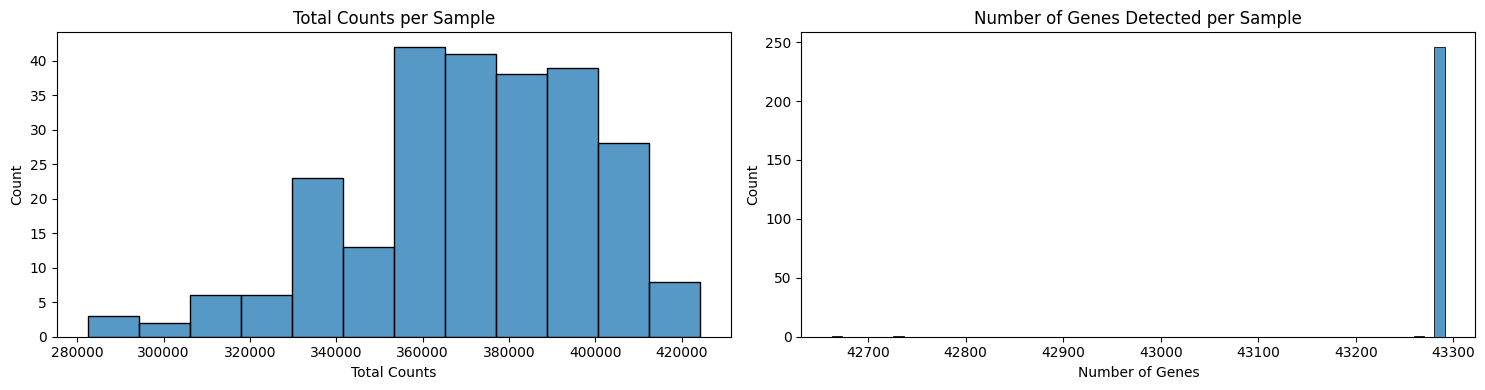

In [ ]:
# Histograms
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(adata_ma.obs["total_counts"], kde=False, ax=axs[0])
axs[0].set_title('Total Counts per Sample')
axs[0].set_xlabel('Total Counts')

sns.histplot(adata_ma.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[1])
axs[1].set_title('Number of Genes Detected per Sample')
axs[1].set_xlabel('Number of Genes')

plt.tight_layout()
plt.show()

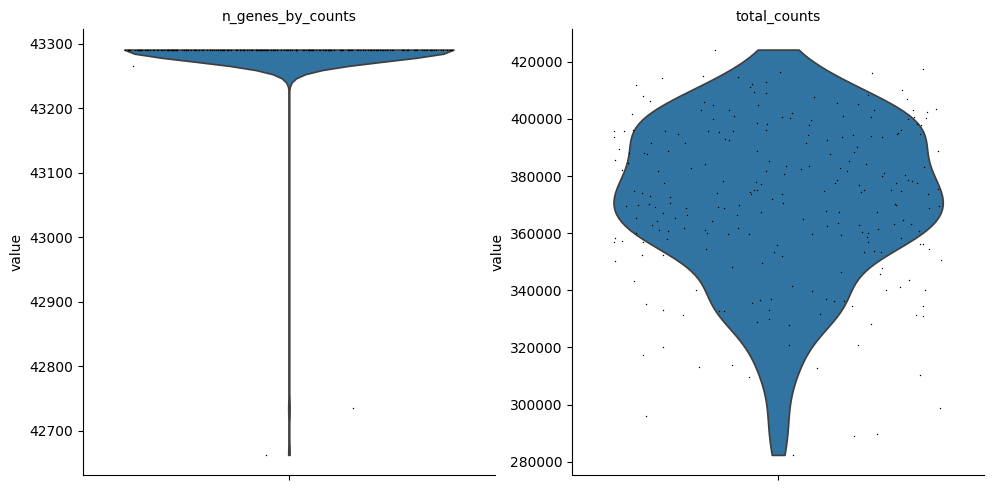

In [ ]:
# Violin plots
sc.pl.violin(adata_ma, ['n_genes_by_counts', 'total_counts'],
             jitter=0.4, multi_panel=True)

In [ ]:
sc.pp.filter_cells(adata_ma, min_genes=43285)

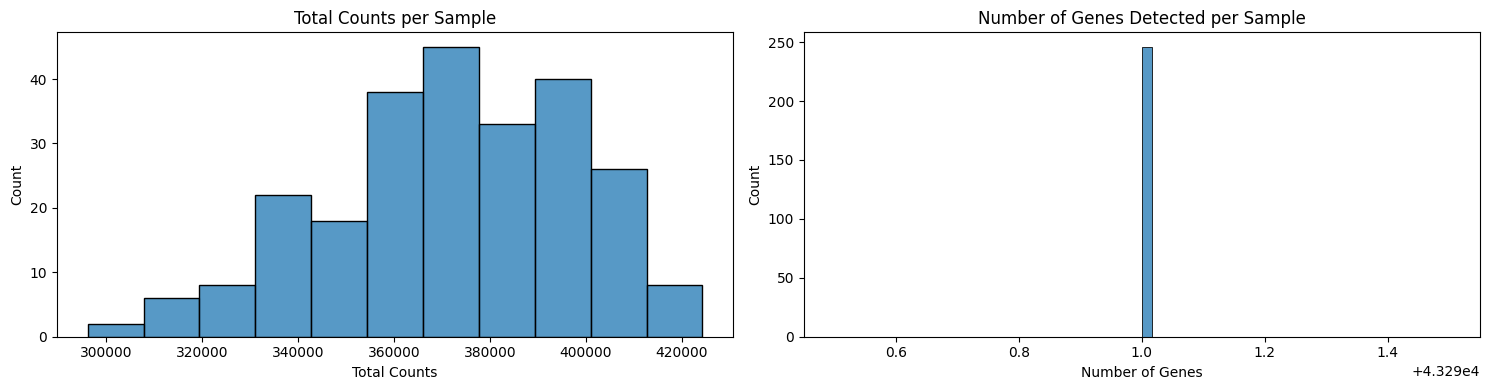

In [ ]:
# Histograms
fig, axs = plt.subplots(1, 2, figsize=(15, 4))
sns.histplot(adata_ma.obs["total_counts"], kde=False, ax=axs[0])
axs[0].set_title('Total Counts per Sample')
axs[0].set_xlabel('Total Counts')

sns.histplot(adata_ma.obs["n_genes_by_counts"], kde=False, bins=60, ax=axs[1])
axs[1].set_title('Number of Genes Detected per Sample')
axs[1].set_xlabel('Number of Genes')

plt.tight_layout()
plt.show()

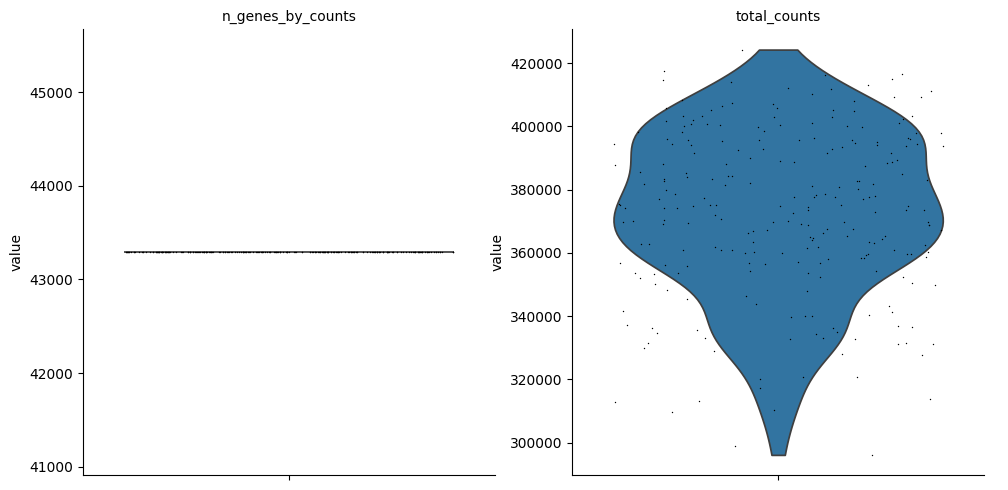

In [ ]:
# Violin plots
sc.pl.violin(adata_ma, ['n_genes_by_counts', 'total_counts'],
             jitter=0.4, multi_panel=True)

In [ ]:
# Sum the gene expression counts across cells
gene_counts_sum = np.sum(adata_ma.X, axis=0)
# Find the gene with the highest sum
gene_with_most_counts = adata_ma.var_names[np.argmax(gene_counts_sum)]
print("Gene with the most counts:", gene_with_most_counts)

Gene with the most counts: 7216


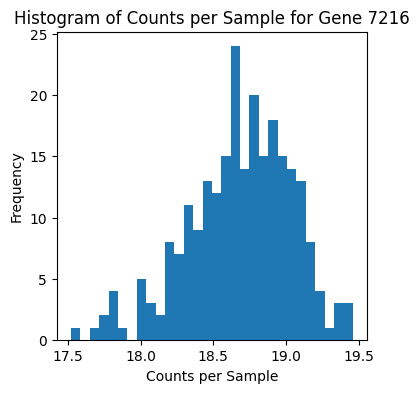

In [ ]:
gene_name = '7216'
gene_index = list(adata_ma.var_names).index(gene_name)
gene_counts_array = adata_ma.X[:, gene_index].flatten()

plt.hist(gene_counts_array, bins=30)
plt.title(f"Histogram of Counts per Sample for Gene {gene_name}")
plt.xlabel("Counts per Sample")
plt.ylabel("Frequency")
plt.show()

In [ ]:
sc.pp.normalize_total(adata_ma, inplace=True, target_sum=1e4)

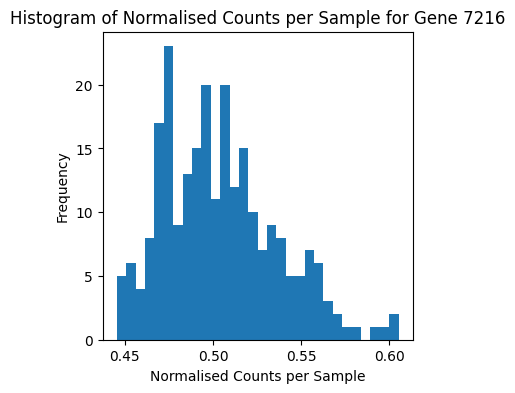

In [ ]:
# Get the normalized gene expression counts for the gene
gene_counts_normalized = adata_ma.X[:, gene_index]

# Flatten the array
gene_counts_normalized_array = gene_counts_normalized.flatten()

# Plot the histogram
plt.hist(gene_counts_normalized_array, bins=30)
plt.title(f"Histogram of Normalised Counts per Sample for Gene {gene_name}")
plt.xlabel("Normalised Counts per Sample")
plt.ylabel("Frequency")
plt.show()

In [ ]:
sc.pp.log1p(adata_ma)

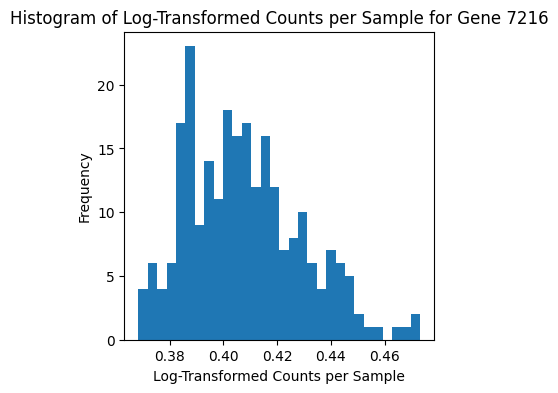

In [ ]:
# Get the log-transformed gene expression counts for the gene
gene_counts_log_transformed = adata_ma.X[:, gene_index]

# Convert sparse matrix to array
gene_counts_log_transformed_array = gene_counts_log_transformed.flatten()

# Plot the histogram
plt.hist(gene_counts_log_transformed_array, bins=30)
plt.title(f"Histogram of Log-Transformed Counts per Sample for Gene {gene_name}")
plt.xlabel("Log-Transformed Counts per Sample")
plt.ylabel("Frequency")
plt.show()

In [ ]:
sc.pp.highly_variable_genes(adata_ma, flavor="seurat", n_top_genes=2000)

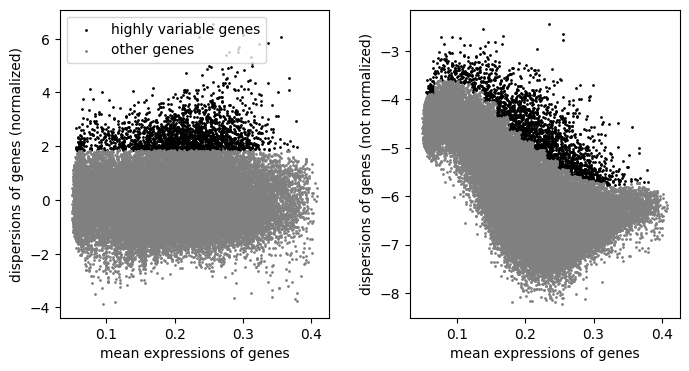

In [ ]:
sc.pl.highly_variable_genes(adata_ma)

In [ ]:
adata_ma = adata_ma[:, adata_ma.var.highly_variable]

In [ ]:
sc.pp.pca(adata_ma)

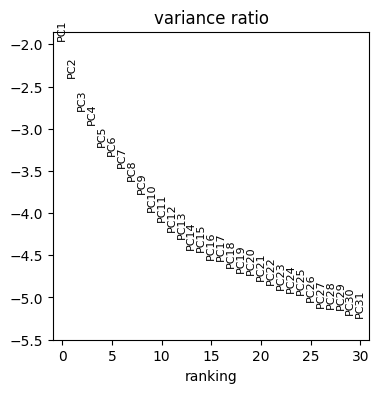

In [ ]:
sc.pl.pca_variance_ratio(adata_ma, log=True)

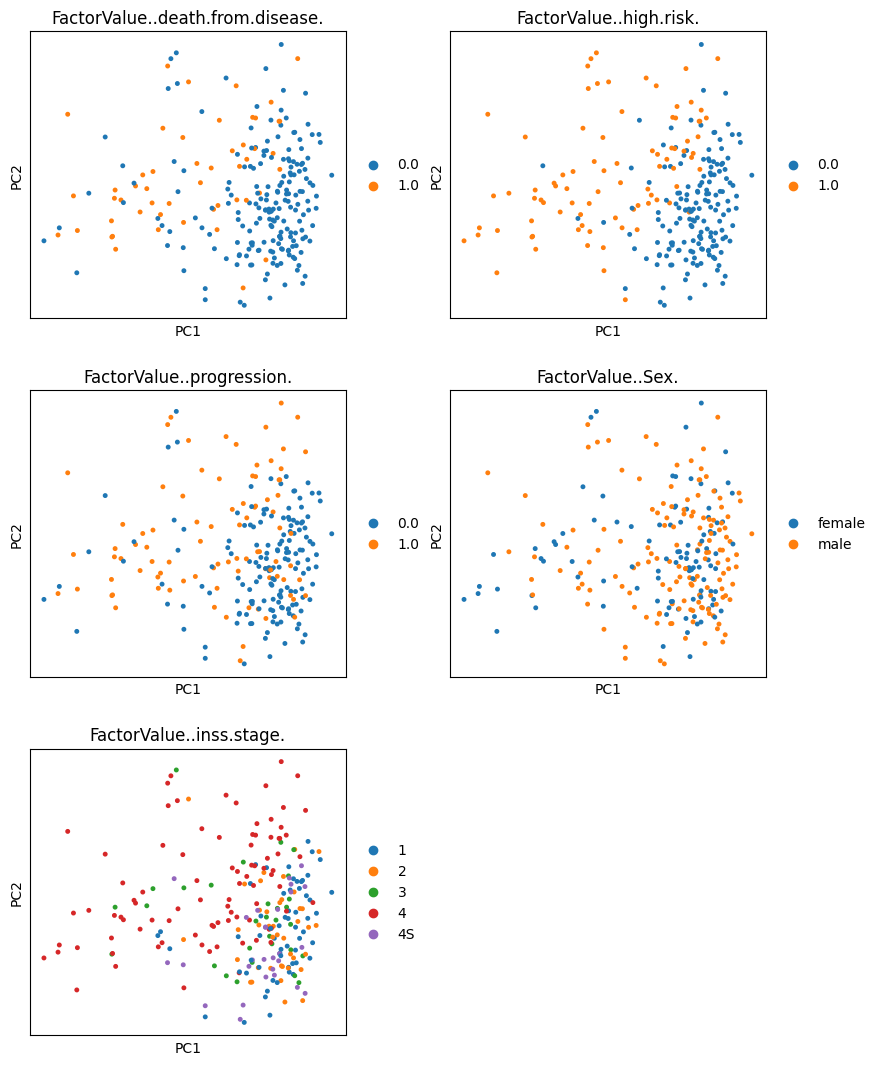

In [ ]:
# Convert to categorical fir plotting
adata_ma.obs["FactorValue..death.from.disease."] = adata_ma.obs["FactorValue..death.from.disease."].astype(str).astype("category")
adata_ma.obs["FactorValue..high.risk."] = adata_ma.obs["FactorValue..high.risk."].astype(str).astype("category")
adata_ma.obs["FactorValue..progression."] = adata_ma.obs["FactorValue..progression."].astype(str).astype("category")

# Plot
sc.pl.pca(
    adata_ma,
    color=["FactorValue..death.from.disease.", "FactorValue..high.risk.", "FactorValue..progression.", "FactorValue..Sex.", "FactorValue..inss.stage."],
    dimensions=[(0, 1), (0, 1), (0, 1), (0, 1), (0, 1)],
    ncols=2,
    size=50,
)

In [ ]:
sc.pp.neighbors(adata_ma, n_pcs=20)

In [ ]:
sc.tl.umap(adata_ma, n_components=2)

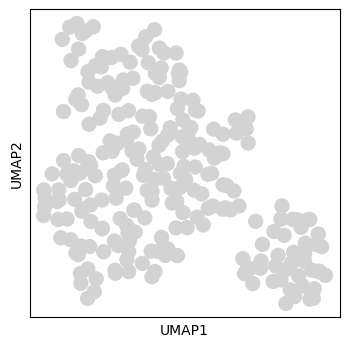

In [ ]:
sc.pl.umap(adata_ma)

In [ ]:
sorted_by_num_cells = adata_ma.var['n_cells_by_counts'].sort_values(ascending=False)
sorted_by_num_cells

,n_cells_by_counts
31950,249
29795,249
38902,249
40211,249
31949,249
...,...
22912,247
23683,247
24279,247
18065,247


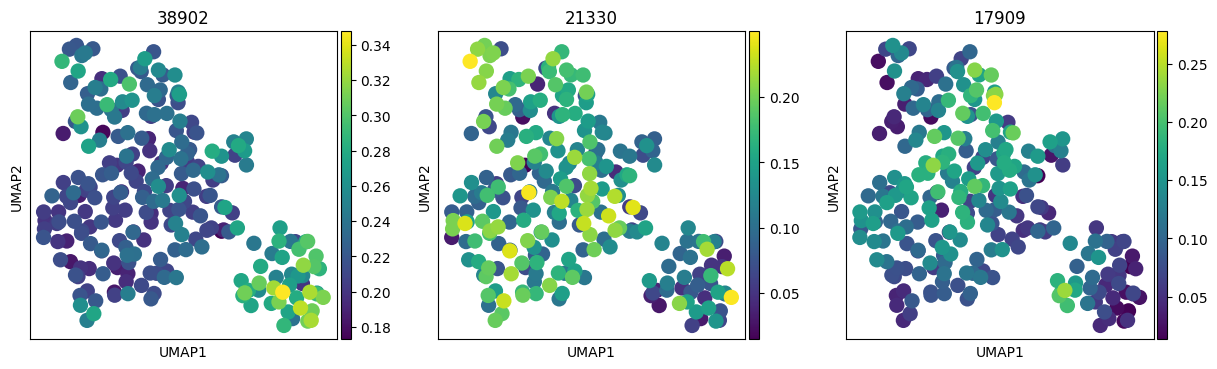

In [ ]:
# Plot by genes identifiers
sc.pl.umap(adata_ma, color=["38902", "21330", "17909"])

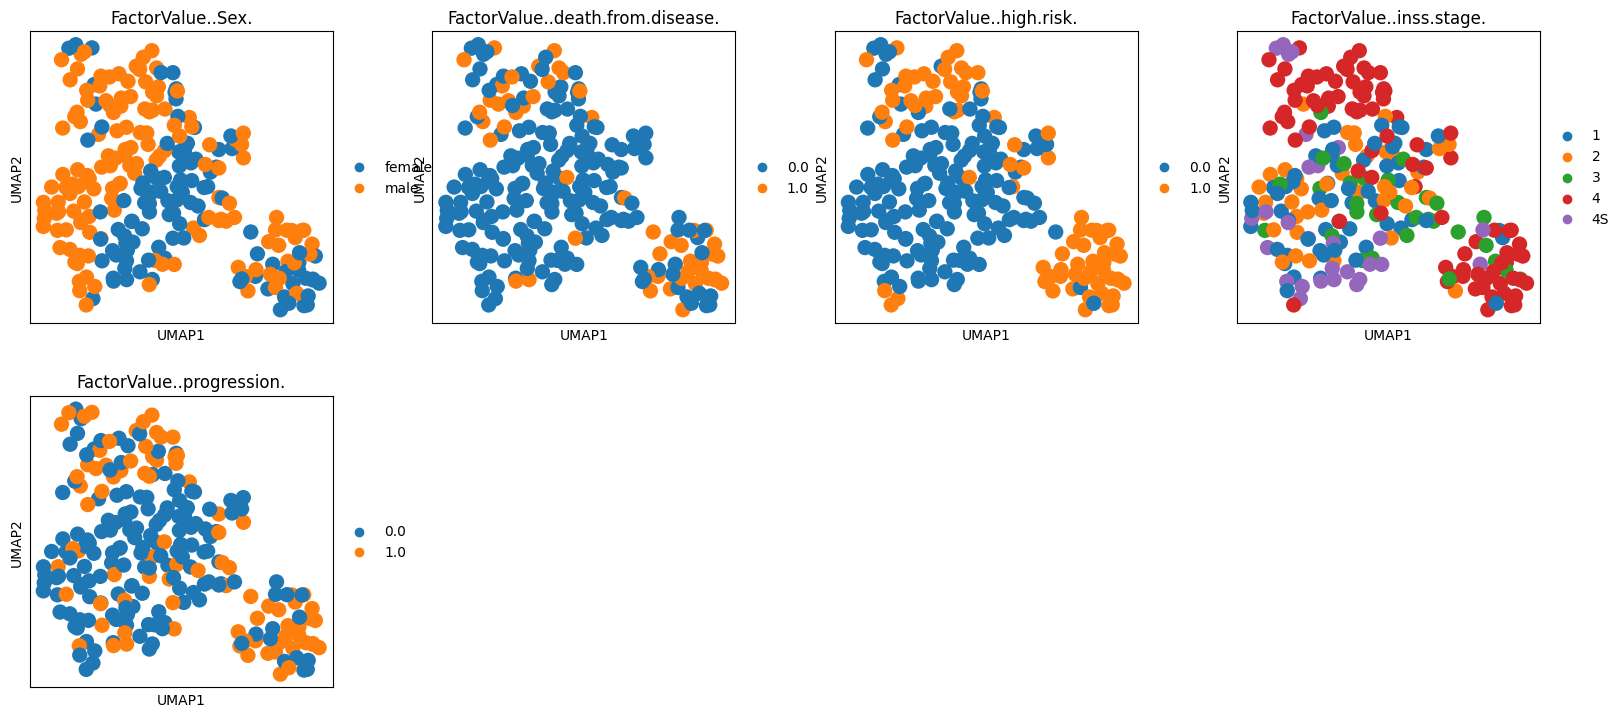

In [ ]:
# Plot by clinical outcome
sc.pl.umap(adata_ma, color=['FactorValue..Sex.',
    'FactorValue..death.from.disease.',
    'FactorValue..high.risk.',
    'FactorValue..inss.stage.',
    'FactorValue..progression.'])

In [ ]:
sc.tl.leiden(adata_ma, resolution=0.6, key_added="clusters")

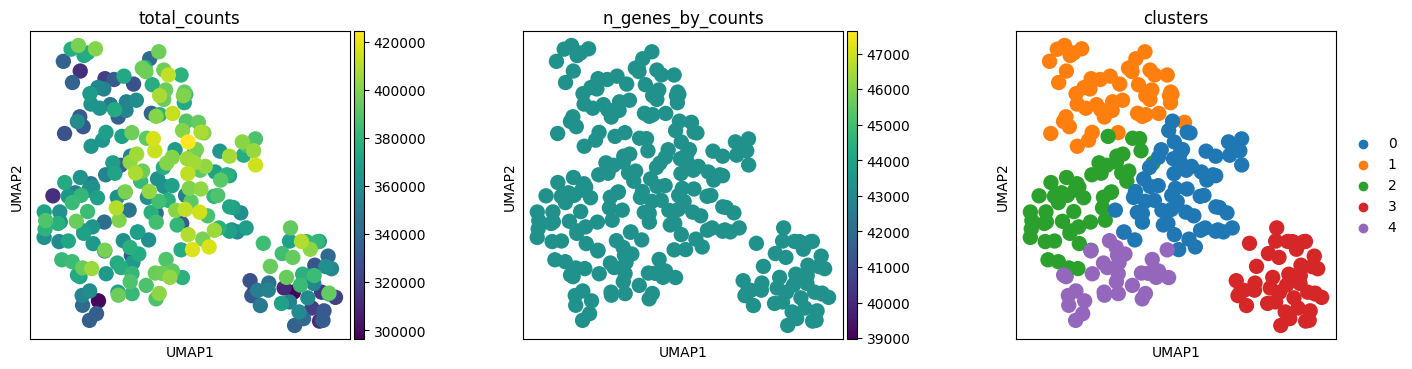

In [ ]:
plt.rcParams["figure.figsize"] = (4, 4)
sc.pl.umap(adata_ma, color=["total_counts", "n_genes_by_counts", "clusters"], wspace=0.4)

In [ ]:
sc.tl.rank_genes_groups(adata_ma, "clusters", method="t-test")

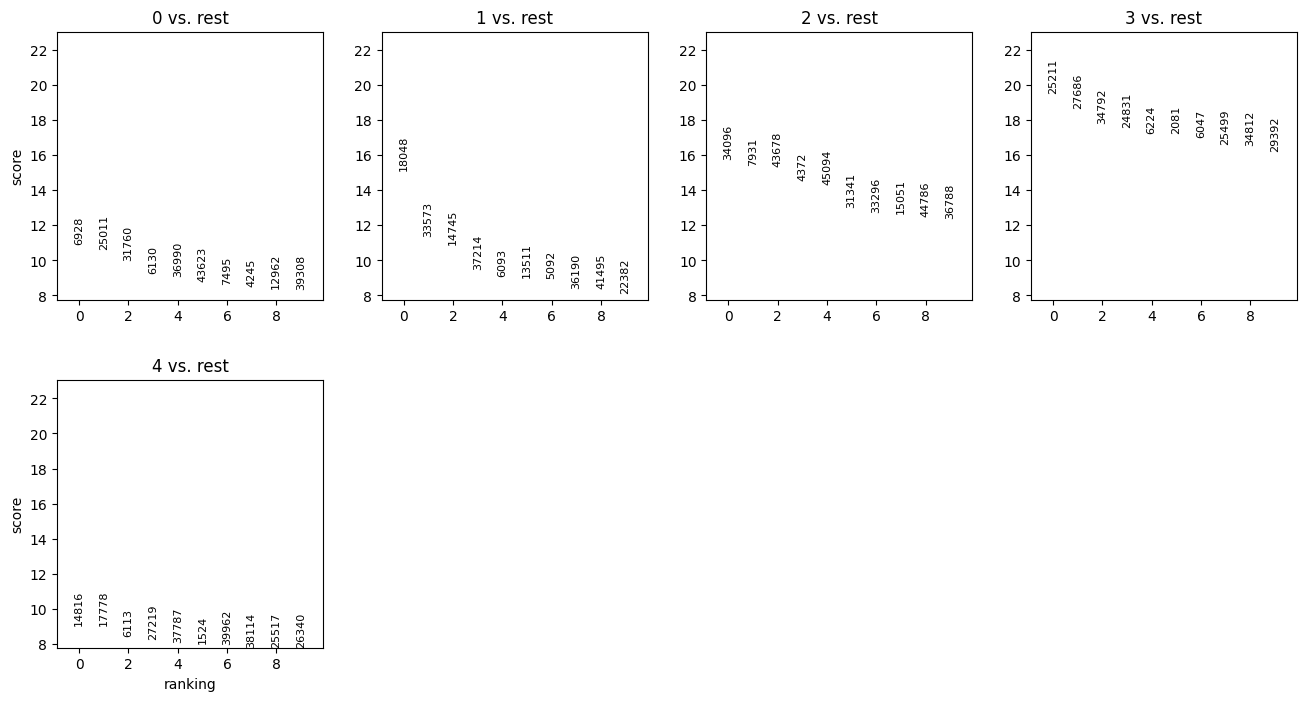

In [ ]:
sc.pl.rank_genes_groups(adata_ma, n_genes=10)

categories: 0, 1, 2, etc.
var_group_labels: 0, 1


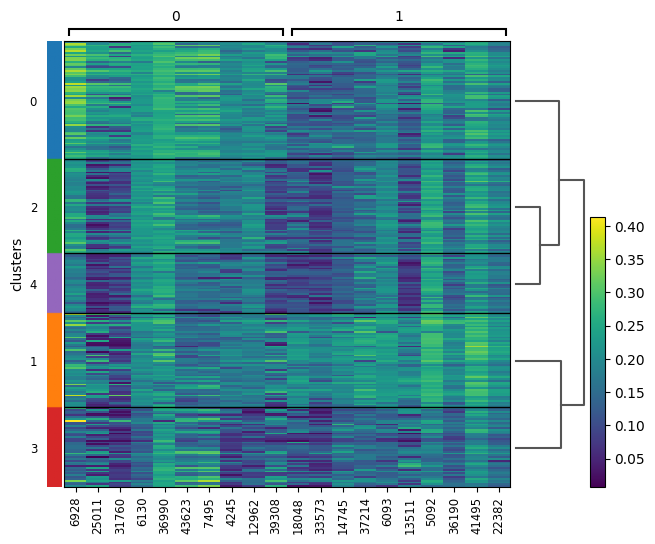

In [ ]:
# Show marker genes for multiple clusters
sc.pl.rank_genes_groups_heatmap(adata_ma, groups=["0", "1"], n_genes=10, groupby="clusters")

In [ ]:
# Obtain the top features for each cluster
result = adata_ma.uns["rank_genes_groups"]
groups = result["names"].dtype.names
top_features = {}
n_top_genes = 10  # desired number of top genes per cluster
for group in groups:
    top_features[group] = result["names"][group][:n_top_genes]

# Print the top features for each cluster
for group, features in top_features.items():
    print(f"Cluster {group} top features:")
    for feature in features:
        print(feature)
    print()

Cluster 0 top features:
6928
25011
31760
6130
36990
43623
7495
4245
12962
39308

Cluster 1 top features:
18048
33573
14745
37214
6093
13511
5092
36190
41495
22382

Cluster 2 top features:
34096
7931
43678
4372
45094
31341
33296
15051
44786
36788

Cluster 3 top features:
25211
27686
34792
24831
6224
2081
6047
25499
34812
29392

Cluster 4 top features:
14816
17778
6113
27219
37787
1524
39962
38114
25517
26340

